
# 3D Volume ??Heatmap (MONAI) ??**PyVista edition**
Interactive 3D volume + heatmap rendering using **PyVista (trame backend)**.  
- Points are **(x, y, z)** in *voxel index* order (MONAI/ITK-style physical coordinate order).  
- The base volume is shown in grayscale; the Gaussian heatmap is overlaid in a hot colormap.

> If you don't have the deps, install first:
```bash
pip install monai torch numpy matplotlib pyvista[trame] medmnist
```


In [1]:

import numpy as np
import torch
import matplotlib.pyplot as plt

from monai.transforms.post.array import GenerateHeatmap
from monai.transforms.post.dictionary import GenerateHeatmapd
from monai.data import MetaTensor

# Optional data source (MedMNIST)
HAS_MEDMNIST = False
try:
    from medmnist import OrganMNIST3D
    HAS_MEDMNIST = True
except Exception:
    print("medmnist not available. Fallback to synthetic volume.")

# PyVista (3D rendering)
HAS_PYVISTA = True
try:
    import pyvista as pv
    pv.set_jupyter_backend("trame")  # interactive in-notebook UI
except Exception as e:
    HAS_PYVISTA = False
    print("PyVista or trame backend not available:", e)


In [2]:

# --- Load a 3D test volume ---
if HAS_MEDMNIST:
    ds = OrganMNIST3D(split="test", download=True, as_rgb=False)
    vol = np.asarray(ds[0][0])
    if vol.ndim == 4:  # (C, D, H, W) -> (D, H, W)
        vol = vol[0]
else:
    # Synthetic 3D blob (D=H=W=28)
    D = H = W = 28
    z, y, x = np.mgrid[0:D, 0:H, 0:W]
    vol = np.exp(-((x-14)**2 + (y-14)**2 + (z-14)**2) / (2*5.0**2)).astype(np.float32)

# Normalize for nicer visualization
vol = vol.astype(np.float32)
if vol.max() > 0:
    vol = vol / float(vol.max())

D, H, W = vol.shape
print("Volume shape (D, H, W) =", (D, H, W))

# Reference MetaTensor for dictionary-based transform (identity affine)
ref = MetaTensor(torch.from_numpy(vol).unsqueeze(0), affine=torch.eye(4))
ref.meta["spatial_shape"] = (D, H, W)


Volume shape (D, H, W) = (28, 28, 28)


In [ ]:
# --- Heatmap generators ---
def heatmap3d_array(points_xyz: np.ndarray, sigma: float = 2.0):
    """Return (B, N, D, H, W) heatmap from landmarks specified as (x, y, z)."""
    if points_xyz.ndim == 2:  # (N, 3)
        points_xyz = points_xyz[np.newaxis, ...]  # -> (1, N, 3)
    points_zyx = points_xyz[..., [2, 1, 0]].copy()  # reorder to (z,y,x) for MONAI
    tr = GenerateHeatmap(sigma=float(sigma), spatial_shape=(D, H, W))
    hm = tr(points_zyx)  # (B, N, D, H, W)
    return hm

def heatmap3d_dict(points_xyz: np.ndarray, sigma: float = 2.0, use_ref: bool = True):
    """Return (B, N, D, H, W) heatmap from landmarks specified as (x, y, z)."""
    if points_xyz.ndim == 2:  # (N, 3)
        points_xyz = points_xyz[np.newaxis, ...]  # -> (1, N, 3)
    points_zyx = points_xyz[..., [2, 1, 0]].copy()  # reorder to (z,y,x) for MONAI
    tr = GenerateHeatmapd(
        keys="points",
        heatmap_keys="heatmap",
        ref_image_keys="ref" if use_ref else None,
        spatial_shape=None if use_ref else (D, H, W),
        sigma=float(sigma),
    )
    data = {"points": points_zyx, "ref": ref}
    out = tr(data)
    return out["heatmap"]  # Tensor or np.ndarray, shape (B, N, D, H, W)

IndexError: index 14 is out of bounds for axis 0 with size 1

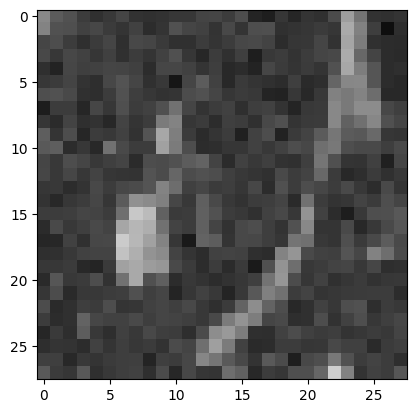

In [ ]:
# --- Quick 2D sanity check (central slice) ---
# This confirms that an (x,y,z) input maps to the expected (z,y,x) voxel index.
points_xyz = np.array([[W // 2, H // 2, D // 2]], dtype=np.float32)
sigma = 2.0

hm_batch = heatmap3d_array(points_xyz, sigma=sigma)
hm = hm_batch.squeeze(0).squeeze(0)  # (D,H,W)
z_idx = int(points_xyz[0, 2])

fig, ax = plt.subplots()
ax.imshow(vol[z_idx], cmap="gray", vmin=0.0, vmax=1.0)
ax.imshow(hm[z_idx], alpha=0.6, cmap="hot")
ax.set_title(f"2D check @ z={z_idx} | input(x,y,z)=({points_xyz[0,0]:.1f},{points_xyz[0,1]:.1f},{points_xyz[0,2]:.1f}) | sigma={sigma:.1f}")
ax.set_axis_off()
plt.show()

In [ ]:
# --- PyVista 3D volume rendering ---
def render_3d_pyvista(points_xyz: np.ndarray, sigma: float = 2.0, use_dict: bool = False):
    if not HAS_PYVISTA:
        raise RuntimeError("PyVista backend is not available in this environment.")

    # Build heatmap (B, N, D, H, W)
    if use_dict:
        hm_any = heatmap3d_dict(points_xyz, sigma=sigma, use_ref=True)
    else:
        hm_any = heatmap3d_array(points_xyz, sigma=sigma)

    # Combine heatmaps (max projection over channel dimension)
    if hasattr(hm_any, "cpu"):
        hm_combined = hm_any.cpu().numpy().max(axis=1).squeeze(0)  # (D,H,W)
    else:
        hm_combined = hm_any.max(axis=1).squeeze(0)

    print(f"Rendering 3D volume with {points_xyz.shape[0]} landmark(s) | sigma={sigma:.1f}")

    # Wrap numpy arrays directly; PyVista understands (Z,Y,X) ordering for UniformGrid
    grid_vol = pv.wrap(vol)  # (D,H,W)
    grid_hm = pv.wrap(hm_combined)  # (D,H,W)

    p = pv.Plotter()
    # Base volume (grayscale-ish)
    p.add_volume(grid_vol, cmap="bone", opacity="sigmoid_6", shade=True)
    # Heatmap overlay (hot colormap, more transparent)
    p.add_volume(grid_hm, cmap="hot", opacity="sigmoid_3", shade=True)
    p.show()

# Example: try moving the landmark; call this cell repeatedly with new values.
render_3d_pyvista(np.array([[14.0, 10.0, 18.0], [20.0, 20.0, 10.0]]), sigma=3.0, use_dict=False)